
 IMAGE ANALYSIS
Type: Normal
Brightness: 150.34987182617186
Contrast: 50.94204985694801
Strategy:
- No Enhancement


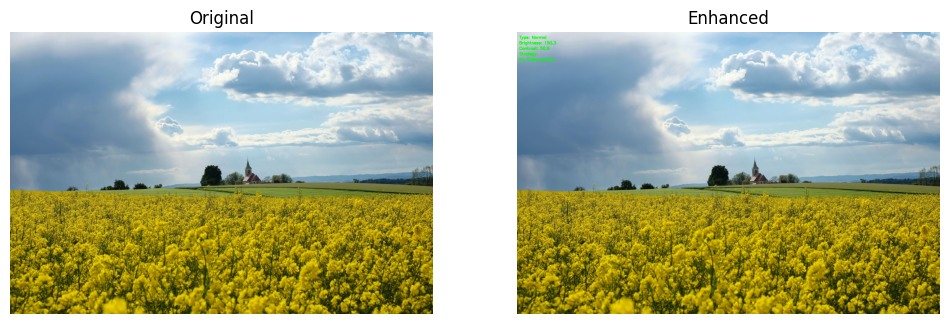


Saved as enhanced_output.jpg


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


class IntelligentEnhancer:

    # Analyze image

    def analyze_image(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        brightness = np.mean(gray)
        contrast = np.std(gray)

        return {
            "brightness": brightness,
            "contrast": contrast
        }


    # Classify image

    def classify_image(self, stats):
        brightness = stats["brightness"]
        contrast = stats["contrast"]

        if brightness < 80:
            return "Dark"
        elif brightness > 180:
            return "Bright"
        elif contrast < 50:
            return "Low Contrast"
        else:
            return "Normal"


    # Gamma correction

    def gamma_correction(self, image, gamma):
        invGamma = 1.0 / gamma
        table = np.array([
            ((i / 255.0) ** invGamma) * 255 for i in range(256)
        ]).astype("uint8")
        return cv2.LUT(image, table)


    # CLAHE

    def apply_clahe(self, image, clip=2.0):
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
        l = clahe.apply(l)

        merged = cv2.merge((l, a, b))
        return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)


    # Sharpen

    def sharpen(self, image):
        kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
        return cv2.filter2D(image, -1, kernel)


    # Denoise

    def denoise(self, image):
        return cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)


    # Enhancement methods

    def enhance_dark(self, image):
        image = self.gamma_correction(image, 1.5)
        image = self.apply_clahe(image, 2.0)
        image = self.denoise(image)
        image = self.sharpen(image)

        strategy = [
            "Gamma (1.5)",
            "CLAHE",
            "Denoise",
            "Sharpen"
        ]
        return image, strategy

    def enhance_bright(self, image):
        image = self.gamma_correction(image, 0.7)
        image = cv2.convertScaleAbs(image, alpha=1.2, beta=-20)
        image = self.apply_clahe(image, 1.5)
        image = self.sharpen(image)

        strategy = [
            "Gamma (0.7)",
            "Contrast Adjust",
            "CLAHE",
            "Sharpen"
        ]
        return image, strategy

    def enhance_low_contrast(self, image):
        image = self.apply_clahe(image, 3.0)
        image = self.gamma_correction(image, 1.2)
        image = self.sharpen(image)

        strategy = [
            "CLAHE",
            "Gamma (1.2)",
            "Sharpen"
        ]
        return image, strategy


    # pipeline

    def enhance(self, image):
        stats = self.analyze_image(image)
        category = self.classify_image(stats)

        if category == "Dark":
            enhanced, strategy = self.enhance_dark(image)

        elif category == "Bright":
            enhanced, strategy = self.enhance_bright(image)

        elif category == "Low Contrast":
            enhanced, strategy = self.enhance_low_contrast(image)

        else:
            enhanced = image.copy()
            strategy = ["No Enhancement"]

        return enhanced, category, stats, strategy



# Draw text on image

def draw_info(image, category, stats, strategy):
    output = image.copy()

    lines = [
        f"Type: {category}",
        f"Brightness: {stats['brightness']:.1f}",
        f"Contrast: {stats['contrast']:.1f}",
        "Strategy:"
    ] + strategy

    y = 30
    for line in lines:
        cv2.putText(output, line, (10, y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0, 255, 0), 2)
        y += 25

    return output



# Show results

def show_results(original, enhanced):
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(enhanced_rgb)
    plt.title("Enhanced")
    plt.axis("off")

    plt.show()



# MAIN

if __name__ == "__main__":

    image_path = "/content/normalcontrast task3.jpg"  #img path
    image = cv2.imread(image_path)

    if image is None:
        print("Error loading image")
        exit()

    enhancer = IntelligentEnhancer()

    enhanced, category, stats, strategy = enhancer.enhance(image)

    # Print info
    print("\n IMAGE ANALYSIS")
    print("Type:", category)
    print("Brightness:", stats["brightness"])
    print("Contrast:", stats["contrast"])
    print("Strategy:")
    for s in strategy:
        print("-", s)

    # Draw info on output image
    annotated = draw_info(enhanced, category, stats, strategy)

    # Show results
    show_results(image, annotated)

    # Save
    cv2.imwrite("enhanced_output.jpg", annotated)
    print("\nSaved as enhanced_output.jpg")